In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/customer_features.csv')

snapshot_date = pd.to_datetime(df['last_purchase']).max() + pd.Timedelta(days=1)

rfm = pd.DataFrame()
rfm['CustomerID']  = df['CustomerID']
rfm['Recency']     = df['days_since_last']          # already computed in eda_cleaning1
rfm['Frequency']   = df['total_orders']
rfm['Monetary']    = df['total_spend']

In [2]:
# Score each column 1–5 using quintile ranking
rfm['R'] = pd.qcut(rfm['Recency'],  q=5, labels=[5,4,3,2,1])  # inverted: low recency = 5
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5])

rfm['R'] = rfm['R'].astype(int)
rfm['F'] = rfm['F'].astype(int)
rfm['M'] = rfm['M'].astype(int)

# Combined score string (useful for rule-based labelling)
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score']   = rfm['R'] + rfm['F'] + rfm['M']   # 3–15 range

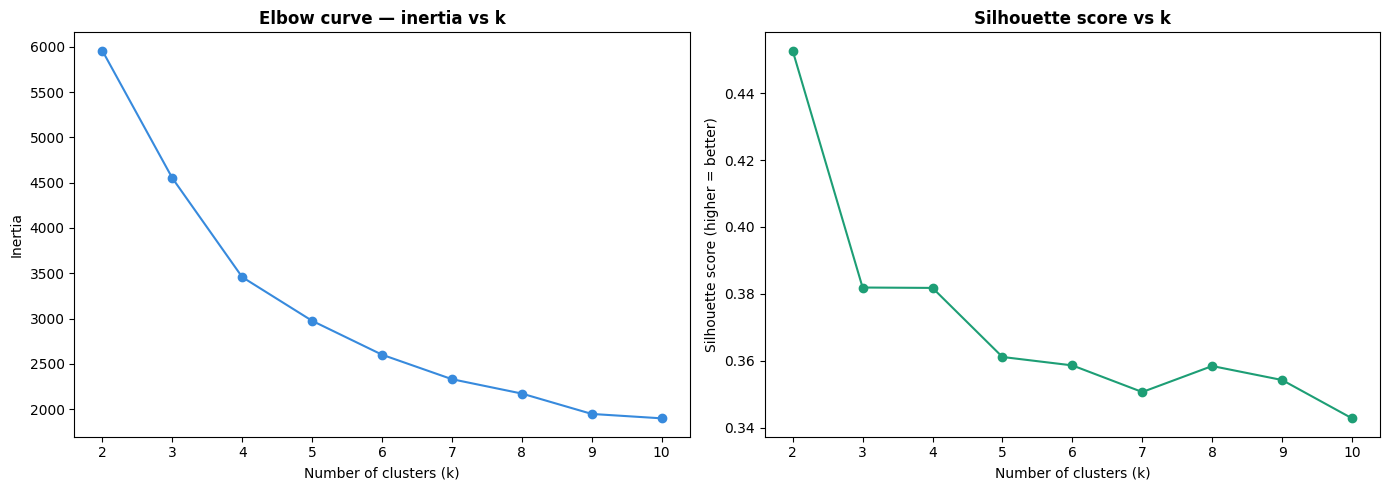

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Scale the features — K-Means uses distance, so scale matters
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R', 'F', 'M']])

# METHOD 1: Elbow curve — plot inertia (within-cluster variance) vs k
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow curve — inertia vs k', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette score vs k', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score (higher = better)')
plt.tight_layout()
plt.show()

In [4]:
# Fit final K-Means with chosen k
BEST_K = 4   # adjust based on your elbow/silhouette plots

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

In [5]:
from sklearn.cluster import DBSCAN

# eps = max distance between two points to be considered neighbours
# min_samples = minimum points to form a dense region (a cluster)
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise    = (rfm['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (outlier customers)")

DBSCAN found 98 clusters and 41 noise points (outlier customers)


In [6]:
# Analyse each cluster's average R, F, M to name them
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary','RFM_Score']].mean()
print(cluster_summary.sort_values('RFM_Score', ascending=False))

# Rule-based mapping — adjust label names after seeing your cluster_summary
def label_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4:
        return 'Cant Lose Them'
    elif r <= 1:
        return 'Lost'
    else:
        return 'Promising'

rfm['Segment'] = rfm.apply(label_segment, axis=1)
print(rfm['Segment'].value_counts())

            Recency  Frequency     Monetary  RFM_Score
Cluster                                               
2         23.635026   9.304636  3488.138690  13.341428
0        125.773653   3.497006  1177.827988   9.346108
3         39.298190   1.567625   370.563174   7.910543
1        238.862241   1.240664   279.794772   4.791701
Segment
Loyal Customers    990
Champions          956
Promising          842
Lost               728
At Risk            453
New Customers      328
Cant Lose Them      41
Name: count, dtype: int64


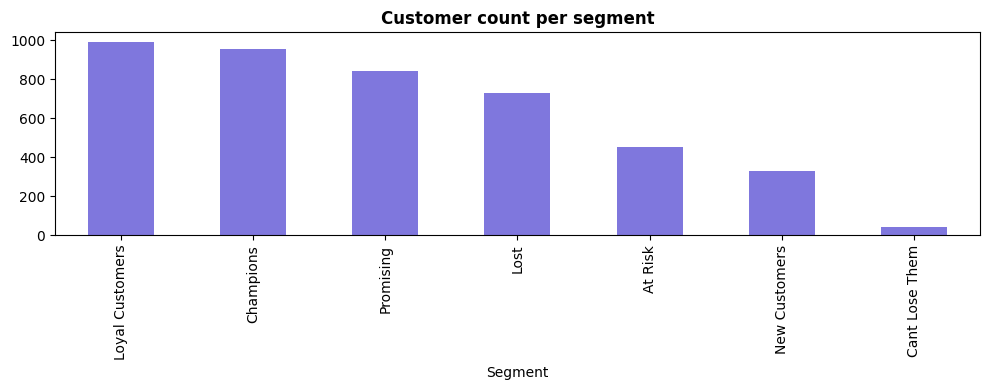

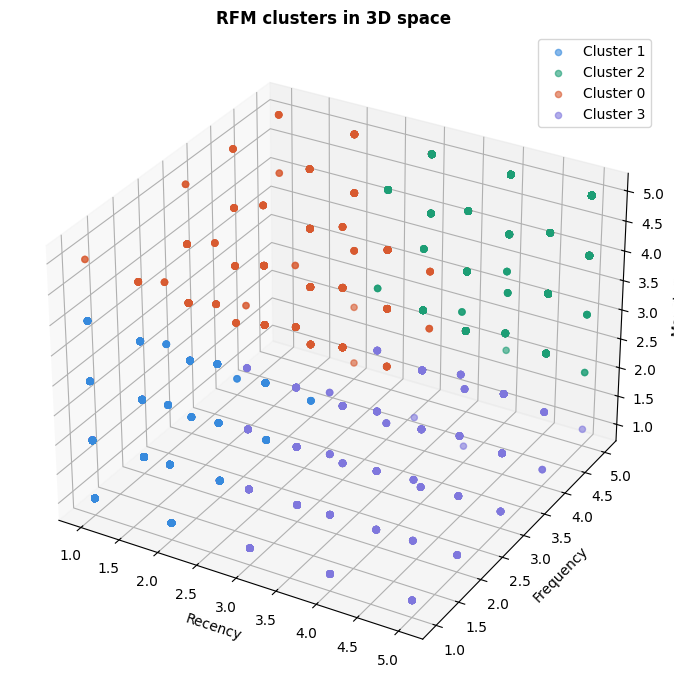

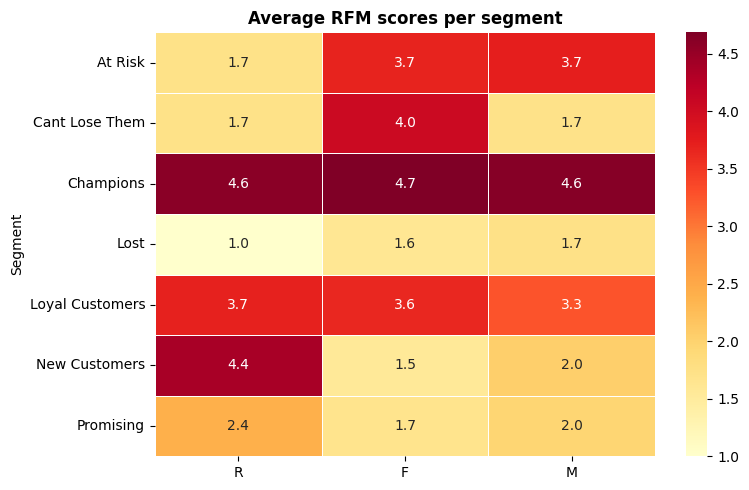

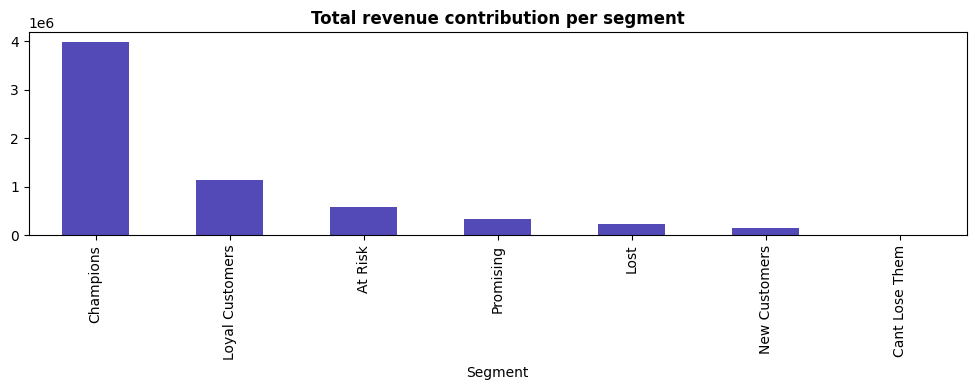

In [7]:
import seaborn as sns

# 1. Segment distribution (bar chart)
rfm['Segment'].value_counts().plot(kind='bar', color='#7F77DD', figsize=(10,4))
plt.title('Customer count per segment', fontweight='bold')
plt.tight_layout(); plt.show()

# 2. 3D scatter — R, F, M coloured by cluster
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax  = fig.add_subplot(111, projection='3d')
colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD','#BA7517','#993556']
for i, cluster in enumerate(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster
    ax.scatter(rfm[mask]['R'], rfm[mask]['F'], rfm[mask]['M'],
               c=colors[i % len(colors)], label=f'Cluster {cluster}', alpha=0.6, s=20)
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('RFM clusters in 3D space', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# 3. Heatmap — average RFM per segment
seg_heatmap = rfm.groupby('Segment')[['R','F','M']].mean()
plt.figure(figsize=(8,5))
sns.heatmap(seg_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average RFM scores per segment', fontweight='bold')
plt.tight_layout(); plt.show()

# 4. Revenue contribution per segment (for business impact)
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
seg_revenue.plot(kind='bar', color='#534AB7', figsize=(10,4))
plt.title('Total revenue contribution per segment', fontweight='bold')
plt.tight_layout(); plt.show()